# Figure 5B: GO Enrichment Comparison — Remove Internal Panel Labels

The current figure has internal labels "A" and "B" that conflict with Figure 5's panel scheme (A, B, C).

**Fix:** Remove "A" and "B" internal labels, keep only descriptive subtitles.

**Instructions:** Upload `go_enrichment_separate.json` and `cross_attn_go_enrichment.json` from `figures/data/` when prompted.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# Upload data files
print("Upload go_enrichment_separate.json and cross_attn_go_enrichment.json")
uploaded = files.upload()

Upload go_enrichment_separate.json and cross_attn_go_enrichment.json


Saving cross_attn_go_enrichment.json to cross_attn_go_enrichment.json
Saving go_enrichment_separate.json to go_enrichment_separate.json


In [2]:
with open('go_enrichment_separate.json', 'r') as f:
    rna_enrichment = json.load(f)
with open('cross_attn_go_enrichment.json', 'r') as f:
    cross_enrichment = json.load(f)

# Community 1 = RNA Self-Attention (679 genes)
# Community 3 = DNA->RNA Cross-Attention (165 genes)
print("RNA Self-Attention communities:", list(rna_enrichment.keys()))
print("Cross-Attention communities:", list(cross_enrichment.keys()))

RNA Self-Attention communities: ['0', '1', '2', '3', '4']
Cross-Attention communities: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52']


In [3]:
def collect_top_terms(enrichment_data, n_top=10):
    """Collect top enrichment terms across all gene set libraries."""
    all_terms = []
    library_map = {
        'GO:BP': 'GO:BP',
        'GO:MF': 'GO:MF',
        'GO:CC': 'GO:CC',
        'KEGG': 'KEGG',
        'Reactome': 'Reactome',
        'Hallmark': 'Hallmark'
    }
    for lib_key, lib_label in library_map.items():
        if lib_key in enrichment_data:
            for term in enrichment_data[lib_key].get('top_terms', []):
                # Clean term name
                name = term['Term']
                # Remove GO ID, KEGG ID etc.
                if '(' in name:
                    name = name[:name.rfind('(')].strip()
                if ' R-HSA-' in name:
                    name = name[:name.find(' R-HSA-')].strip()
                if ' WP' in name:
                    name = name[:name.find(' WP')].strip()

                # Title case
                name = name.title()

                overlap = term['Overlap']
                neg_log_p = -np.log10(term['Adjusted P-value'])
                all_terms.append({
                    'name': name,
                    'overlap': overlap,
                    'neg_log_p': neg_log_p,
                    'library': lib_label
                })

    # Sort by -log10(p) and take top n
    all_terms.sort(key=lambda x: x['neg_log_p'], reverse=True)
    return all_terms[:n_top]

# Get top terms for each community
rna_comm1 = collect_top_terms(rna_enrichment['1'])
cross_comm3 = collect_top_terms(cross_enrichment['3'])

print("RNA Self-Attention Community 1 top terms:")
for t in rna_comm1:
    print(f"  {t['name']} [{t['overlap']}] = {t['neg_log_p']:.1f} ({t['library']})")

print("\nCross-Attention Community 3 top terms:")
for t in cross_comm3:
    print(f"  {t['name']} [{t['overlap']}] = {t['neg_log_p']:.1f} ({t['library']})")

RNA Self-Attention Community 1 top terms:
  Rna Binding [110/1411] = 13.3 (GO:MF)
  Intracellular Membrane-Bounded Organelle [255/5175] = 8.8 (GO:CC)
  Nucleus [222/4487] = 7.4 (GO:CC)
  Metabolism Of Rna [57/666] = 6.8 (Reactome)
  Heme Metabolism [23/200] = 4.8 (Hallmark)
  Intracellular Non-Membrane-Bounded Organelle [75/1195] = 4.8 (GO:CC)
  Metabolism Of Proteins [106/1890] = 4.1 (Reactome)
  Small-Subunit Processome [12/73] = 3.5 (GO:CC)
  Nuclear Lumen [51/780] = 3.5 (GO:CC)
  Myc Targets V1 [20/200] = 3.4 (Hallmark)

Cross-Attention Community 3 top terms:
  Rna Binding [47/1411] = 14.0 (GO:MF)
  Nucleus [82/4487] = 11.7 (GO:CC)
  Intracellular Membrane-Bounded Organelle [87/5175] = 11.0 (GO:CC)
  Rna Processing [16/183] = 8.5 (GO:BP)
  Spliceosome [14/150] = 8.4 (KEGG)
  Mrna Splicing, Via Spliceosome [16/211] = 7.9 (GO:BP)
  Mrna Splicing - Major Pathway [15/181] = 7.8 (Reactome)
  Mrna Splicing [15/189] = 7.8 (Reactome)
  Processing Of Capped Intron-Containing Pre-Mrna [16/24

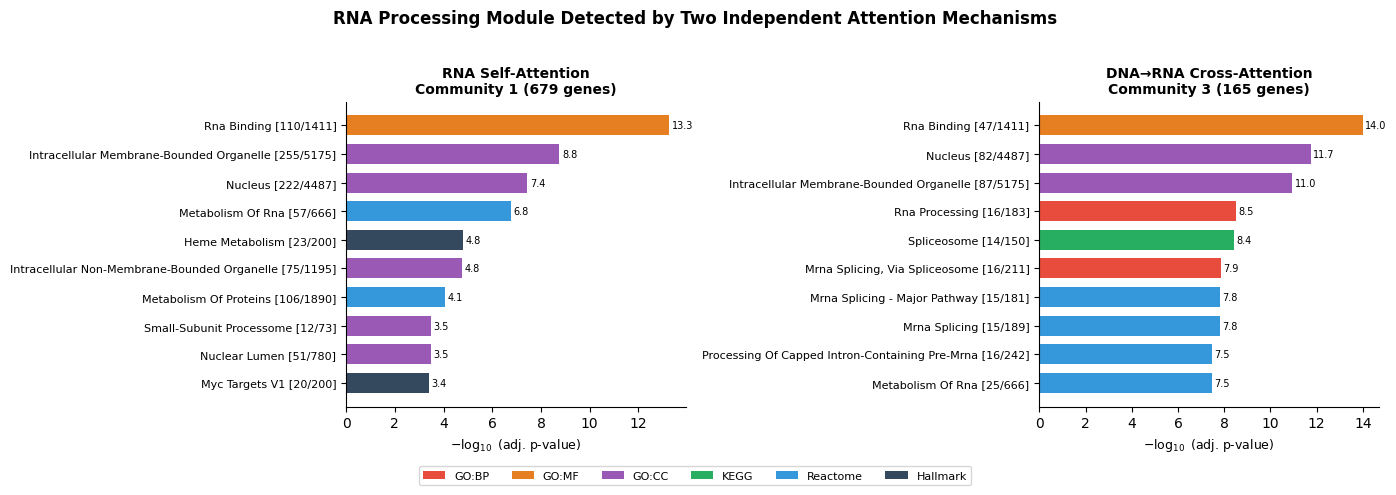

Saved: fig5a_go_enrichment_comparison.png and .pdf


In [4]:
# Color map for gene set libraries
LIBRARY_COLORS = {
    'GO:BP': '#E74C3C',   # Red
    'GO:MF': '#E67E22',   # Orange
    'GO:CC': '#9B59B6',   # Purple
    'KEGG': '#27AE60',    # Green
    'Reactome': '#3498DB', # Blue
    'Hallmark': '#34495E'  # Dark gray
}

def plot_enrichment_panel(ax, terms, subtitle, n_genes):
    """Plot a single enrichment panel."""
    names = [f"{t['name']} [{t['overlap']}]" for t in reversed(terms)]
    values = [t['neg_log_p'] for t in reversed(terms)]
    colors = [LIBRARY_COLORS.get(t['library'], '#999999') for t in reversed(terms)]

    bars = ax.barh(range(len(names)), values, color=colors, edgecolor='none', height=0.7)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel(r'$-\log_{10}$ (adj. p-value)', fontsize=9)
    # NO "A" or "B" prefix - just descriptive subtitle
    ax.set_title(f'{subtitle} ({n_genes} genes)', fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=7)

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Main title
fig.suptitle('RNA Processing Module Detected by Two Independent Attention Mechanisms',
             fontsize=12, fontweight='bold', y=1.02)

# Left: RNA Self-Attention Community 1
plot_enrichment_panel(ax1, rna_comm1, 'RNA Self-Attention\nCommunity 1', 679)

# Right: Cross-Attention Community 3
plot_enrichment_panel(ax2, cross_comm3, 'DNA→RNA Cross-Attention\nCommunity 3', 165)

# Legend for library colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in LIBRARY_COLORS.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('fig5a_go_enrichment_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig5a_go_enrichment_comparison.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig5a_go_enrichment_comparison.png and .pdf')

In [5]:
# Download
files.download('fig5a_go_enrichment_comparison.png')
files.download('fig5a_go_enrichment_comparison.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>